In [1]:
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader

from brise.rise import RISE
from brise.brise import B_RISE
from brise.evaluation import evaluate_saliency, blur_substrate, zero_substrate

import brise.utils as utils
from brise.utils import IMAGES

# MNSIT DATA

## Load Data and Train Model

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.ToTensor()

train_dataset = datasets.MNIST("./data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST("./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=1000, shuffle=False)

In [3]:
class MNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1   = nn.Linear(64 * 7 * 7, 128)
        self.fc2   = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)      # 14x14
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)      # 7x7
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [4]:
model = MNISTCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

epochs = 3

for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.2620
Epoch 2, Loss: 0.0614
Epoch 3, Loss: 0.0439


In [5]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        output = model(x)
        preds = output.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

print("Test Accuracy:", correct / total)

Test Accuracy: 0.9877


## Get IMAGES

In [6]:
def build_digit_example_dict(model, loader, device, max_samples=100):
    model.eval()

    digit_dict = {d: [] for d in range(10)}
    seen = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1)

            for i in range(len(x)):
                seen += 1
                digit = y[i].item()

                if preds[i] == y[i]:  # only correct predictions
                    digit_dict[digit].append((x[i:i+1], y[i:i+1]))

                if seen >= max_samples:
                    break

            if seen >= max_samples:
                break

    return digit_dict

In [7]:
examples = build_digit_example_dict(model, test_loader, device)

## Digit 4

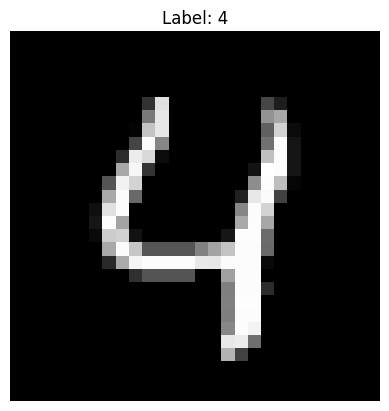

In [8]:
img_x, label = examples[4][0]

plt.imshow(img_x.squeeze().cpu(), cmap="gray")
plt.title(f"Label: {label.item()}")
plt.axis("off")
plt.show()

### B RISE

In [52]:
rise_banzhaf = B_RISE(model, img_x)
rise_banzhaf.generate_masks(N=1000, s=28, p=0.5, mode="nearest")

In [53]:
sal = rise_banzhaf.forward(img_x, K=10, no_shift=False)

Estimated forward passes: 11000


Banzhaf sampling: 100%|██████████| 1000/1000 [00:01<00:00, 531.73it/s]

Total forward passes: 11000


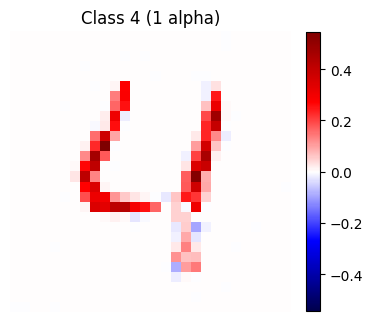

In [54]:
sal_map_brise = utils.draw_saliency_overlay_mnist(img_x, sal, class_id=4, norm_mode="symmetric", alpha = 1)

#### Evaluate

In [58]:
scores_del, auc_del = evaluate_saliency(
    model,
    img_x,
    sal_map_brise,
    mode="del",
    step=5,
    progress_image_count=0,
    substrate_fn=zero_substrate
)

print("Deletion AUC:", auc_del)

Deletion AUC: 0.06925833890819626


In [59]:
scores_ins, auc_ins = evaluate_saliency(
    model,
    img_x,
    sal_map_brise,
    mode="ins",
    step=5,
    progress_image_count=0,
    substrate_fn=zero_substrate
)

print("Insertion AUC:", auc_ins)

Insertion AUC: 0.9781944631438726


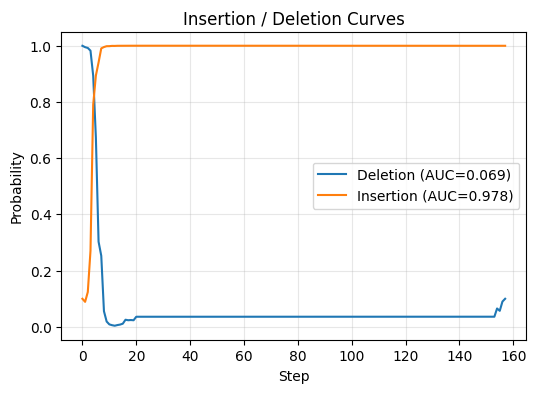

In [60]:
utils.plot_ins_del(scores_ins, auc_ins, scores_del, auc_del)

### RISE

In [39]:
rise = RISE(model, img_x)
rise.generate_masks(N=10000, s=28, p=0.5, no_shift=True, mode="nearest")

Generating filters: 100%|██████████| 10000/10000 [00:00<00:00, 11541.70it/s]


In [40]:
sal_rise = rise.forward(img_x)

Running model: 100%|██████████| 100/100 [00:00<00:00, 293.42it/s]


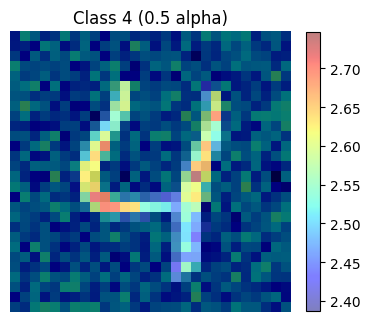

In [42]:
sal_map_rise = utils.draw_saliency_overlay_mnist(img_x, sal_rise, class_id=4, norm_mode="minmax", alpha = 0.5, cmap="jet")

#### Evaluate

In [61]:
scores_del, auc_del = evaluate_saliency(
    model,
    img_x,
    sal_map_rise,
    mode="del",
    step=5,
    progress_image_count=0,
    substrate_fn=zero_substrate
)

print("Deletion AUC:", auc_del)

Deletion AUC: 0.06684047846601102


In [62]:
scores_ins, auc_ins = evaluate_saliency(
    model,
    img_x,
    sal_map_rise,
    mode="ins",
    step=5,
    progress_image_count=0,
    substrate_fn=zero_substrate
)

print("Insertion AUC:", auc_ins)

Insertion AUC: 0.978503021251434


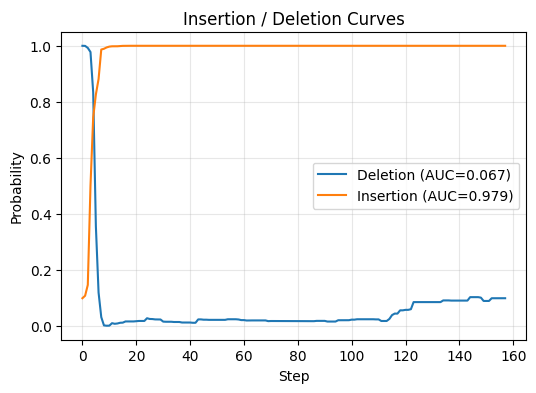

In [63]:
utils.plot_ins_del(scores_ins, auc_ins, scores_del, auc_del)

## Digit 8

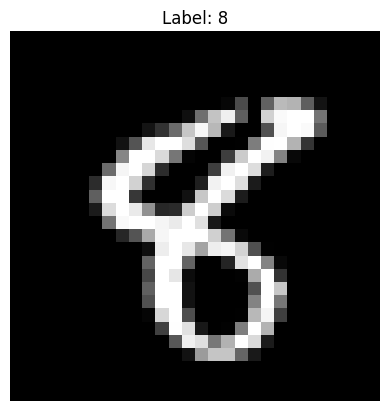

In [166]:
img_x, label = examples[8][1]

plt.imshow(img_x.squeeze().cpu(), cmap="gray")
plt.title(f"Label: {label.item()}")
plt.axis("off")
plt.show()

### B RISE

In [167]:
rise_banzhaf = B_RISE(model, img_x)
rise_banzhaf.generate_masks(N=1000, s=28, p=0.5, mode="nearest")

In [168]:
sal = rise_banzhaf.forward(img_x, K=10, no_shift=False)

Estimated forward passes: 11000


Banzhaf sampling: 100%|██████████| 1000/1000 [00:01<00:00, 585.37it/s]

Total forward passes: 11000


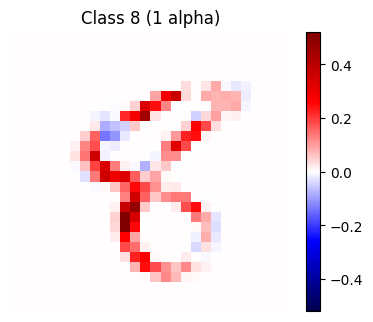

In [169]:
sal_map_brise = utils.draw_saliency_overlay_mnist(img_x, sal, class_id=8, norm_mode="symmetric", alpha = 1)

#### Evaluate

In [170]:
scores_del, auc_del = evaluate_saliency(
    model,
    img_x,
    sal_map_brise,
    mode="del",
    step=5,
    progress_image_count=0,
    substrate_fn=zero_substrate
)

print("Deletion AUC:", auc_del)

Deletion AUC: 0.06924258098362168


In [171]:
scores_ins, auc_ins = evaluate_saliency(
    model,
    img_x,
    sal_map_brise,
    mode="ins",
    step=5,
    progress_image_count=0,
    substrate_fn=zero_substrate
)

print("Insertion AUC:", auc_ins)

Insertion AUC: 0.979476985871602


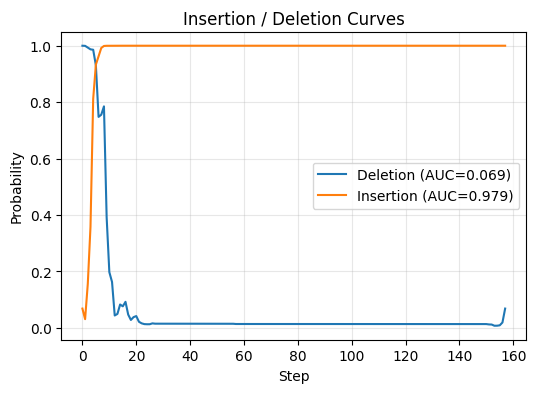

In [172]:
utils.plot_ins_del(scores_ins, auc_ins, scores_del, auc_del)

### RISE

In [173]:
rise = RISE(model, img_x)
rise.generate_masks(N=10000, s=28, p=0.5, no_shift=True, mode="nearest")

Generating filters: 100%|██████████| 10000/10000 [00:00<00:00, 15189.17it/s]


In [174]:
sal_rise = rise.forward(img_x)

Running model: 100%|██████████| 100/100 [00:00<00:00, 417.79it/s]


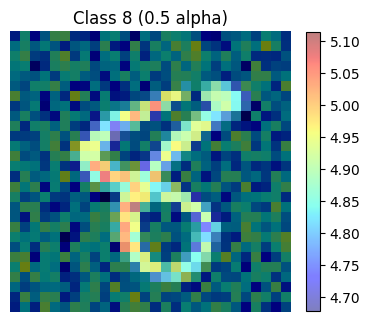

In [175]:
sal_map_rise = utils.draw_saliency_overlay_mnist(img_x, sal_rise, class_id=8, norm_mode="minmax", alpha = 0.5, cmap="jet")

#### Evaluate

In [176]:
scores_del, auc_del = evaluate_saliency(
    model,
    img_x,
    sal_map_rise,
    mode="del",
    step=5,
    progress_image_count=0,
    substrate_fn=zero_substrate
)

print("Deletion AUC:", auc_del)

Deletion AUC: 0.1436656798906387


In [177]:
scores_ins, auc_ins = evaluate_saliency(
    model,
    img_x,
    sal_map_rise,
    mode="ins",
    step=5,
    progress_image_count=0,
    substrate_fn=zero_substrate
)

print("Insertion AUC:", auc_ins)

Insertion AUC: 0.9732260594180056


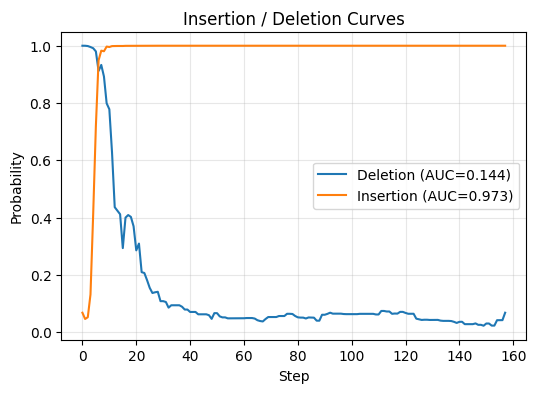

In [178]:
utils.plot_ins_del(scores_ins, auc_ins, scores_del, auc_del)

## Exact Banzhaf

In [64]:
from brise.exact_banzhaf import build_supergrid_mask, exact_banzhaf_supergrid

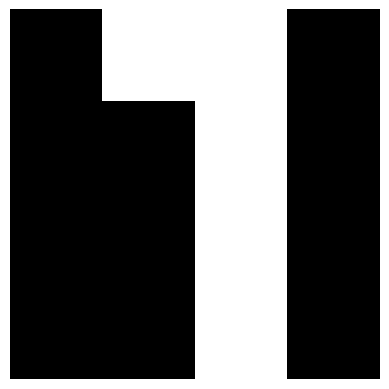

In [65]:
utils.draw_mask(build_supergrid_mask(torch.tensor([0,1,1,0, 
                                                   0,0,1,0, 
                                                   0,0,1,0, 
                                                   0,0,1,0]), 4))

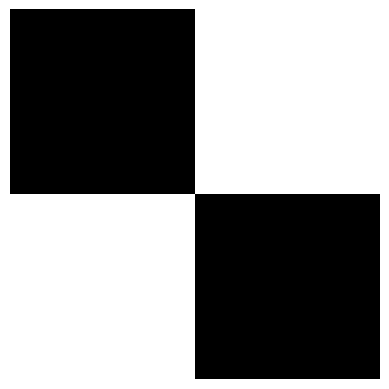

In [66]:
utils.draw_mask(build_supergrid_mask(torch.tensor([0,1, 
                                                   1,0]), 2))

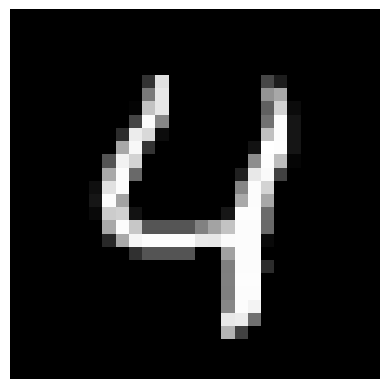

In [67]:
plt.imshow(img_x.cpu().squeeze().numpy(), cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
model(img_x)

tensor([[-4.7102, -4.4178, -3.9184, -7.9790, 11.5039, -5.2150, -2.7351, -0.6163,
         -3.4357,  4.1141]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [69]:
beta = exact_banzhaf_supergrid(model, img_x, s=4)

Computing Banzhaf: 100%|██████████| 16/16 [00:09<00:00,  1.64it/s]


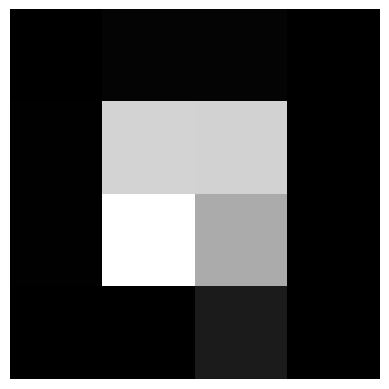

In [70]:
utils.draw_mask(beta[4])

In [71]:
beta[4]

tensor([[ 0.0000e+00,  4.8834e-02,  4.9339e-02,  0.0000e+00],
        [ 2.8011e-03,  2.8586e+00,  2.8366e+00, -1.0926e-02],
        [ 1.2627e-02,  3.4504e+00,  2.3082e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  3.5562e-01,  0.0000e+00]], device='cuda:0')

In [ ]:
# do banzhaf approx
brise_banzhaf = B_RISE(model, img_x)
brise_banzhaf.generate_masks(N=10000, s=4, p=0.5, mode="nearest")

In [ ]:
sal_brise = brise_banzhaf.forward(img_x, no_shift=True, K=2)

Estimated forward passes: 30000


Banzhaf sampling: 100%|██████████| 10000/10000 [00:09<00:00, 1001.02it/s]

Total forward passes: 30000


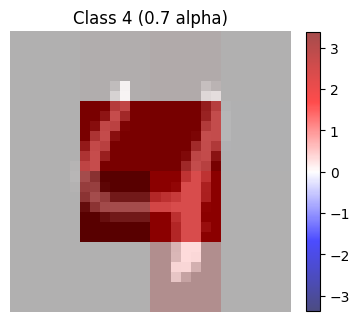

In [136]:
sal_map_brise = utils.draw_saliency_overlay_mnist(img_x, sal_brise, class_id=4, norm_mode="symmetric", alpha = 0.7)

In [137]:
brise_estimate = sal_map_brise.reshape(4,7,4,7).mean(axis=(1,3))
np.set_printoptions(precision=4, suppress=True)
print(brise_estimate)

[[ 0.0001  0.0454  0.0608  0.    ]
 [ 0.0029  2.7294  2.7753 -0.0105]
 [ 0.0133  3.3758  2.3816  0.0001]
 [ 0.0001  0.      0.3397  0.0001]]


Try with p != 0.5

In [152]:
# do banzhaf approx
brise_notbanzhaf = B_RISE(model, img_x)
brise_notbanzhaf.generate_masks(N=10000, s=4, p=0.8, mode="nearest")

In [140]:
sal_brise_notbanzhaf = brise_notbanzhaf.forward(img_x, no_shift=True, K=2)

Estimated forward passes: 30000


Banzhaf sampling: 100%|██████████| 10000/10000 [00:09<00:00, 1014.89it/s]

Total forward passes: 28339


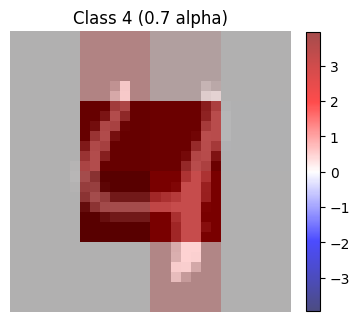

In [153]:
sal_map_brise_notbanzhaf = utils.draw_saliency_overlay_mnist(img_x, sal_brise_notbanzhaf, class_id=4, norm_mode="symmetric", alpha = 0.7)

In [154]:
brise_notbanzhaf_estimate = sal_map_brise_notbanzhaf.reshape(4,7,4,7).mean(axis=(1,3))
np.set_printoptions(precision=4, suppress=True)
print(brise_notbanzhaf_estimate)

[[ 0.0003  0.5069  0.1875  0.0003]
 [ 0.0073  3.6315  3.5037 -0.0213]
 [ 0.0259  3.9486  3.1917  0.0003]
 [ 0.0003  0.0003  0.4736  0.0003]]


In [ ]:
b = beta[4].cpu().numpy().flatten()
br = brise_estimate.flatten()
br_nb = brise_notbanzhaf_estimate.flatten()

mse_brise = np.mean((br - b)**2)
mse_brise_notbanzhaf = np.mean((br_nb - b)**2)

print("MSE BRISE:", mse_brise)
print("MSE BRISE (Not Banzhaf):", mse_brise_notbanzhaf)

MSE BRISE: 0.0019881064
MSE BRISE (Not Banzhaf): 0.14463222


In [155]:
rise = RISE(model, img_x)
rise.generate_masks(N=30000, s=4, p=0.5, mode="nearest", no_shift=True)

Generating filters: 100%|██████████| 30000/30000 [00:01<00:00, 15914.96it/s]


In [156]:
sal_rise = rise.forward(img_x)

Running model: 100%|██████████| 300/300 [00:00<00:00, 716.89it/s]


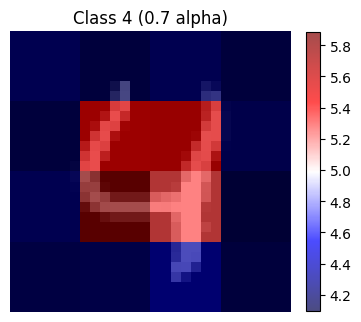

In [157]:
sal_map_rise = utils.draw_saliency_overlay_mnist(img_x, sal_rise, class_id=4, norm_mode="minmax", alpha = 0.7)

In [158]:
rise_estimate = sal_map_rise.reshape(4,7,4,7).mean(axis=(1,3))
np.set_printoptions(precision=4, suppress=True)
print(rise_estimate)

[[4.1927 4.1282 4.1984 4.1281]
 [4.1248 5.5376 5.5587 4.1775]
 [4.1927 5.8826 5.3027 4.0947]
 [4.1485 4.1617 4.3053 4.125 ]]


In [161]:
from scipy.stats import pearsonr, spearmanr

b = beta[4].cpu().numpy().flatten()
br = brise_estimate.flatten()
r = rise_estimate.flatten()

print("Pearson Banzhaf vs BRISE:", pearsonr(b, br)[0])
print("Pearson Banzhaf vs RISE:", pearsonr(b, r)[0])

print("Spearman Banzhaf vs BRISE:", spearmanr(b, br)[0])
print("Spearman Banzhaf vs RISE:", spearmanr(b, r)[0])

Pearson Banzhaf vs BRISE: 0.9995861
Pearson Banzhaf vs RISE: 0.9988911
Spearman Banzhaf vs BRISE: 0.9709048247642865
Spearman Banzhaf vs RISE: 0.7504505410697518
